In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/caishen_bank_transactions.csv')

print(df.shape) # 11 columns, 6 million rows
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [5]:
#Check for null values
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [6]:
# Check for duplicates
print(df.duplicated().sum())

0


### Univariate Analysis

**Looking into *step* column**

Text(0, 0.5, '# of transactions')

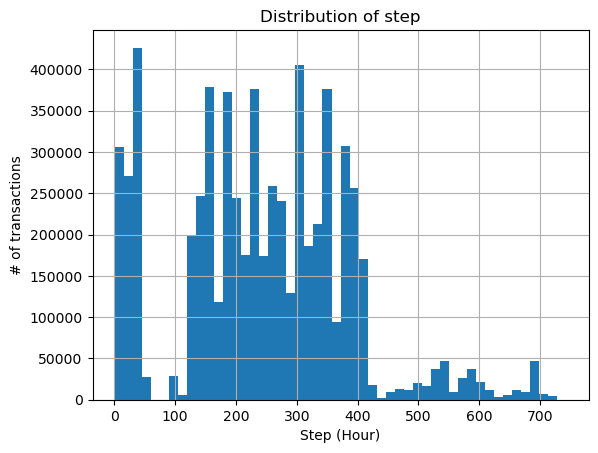

In [7]:
df['step'].hist(bins=50)
plt.title("Distribution of step")
plt.xlabel("Step (Hour)")
plt.ylabel("# of transactions")

- Would step or timestamp be a good predictor of fraud? 
- Is a specific time of day more prone to fraud?
- IDONTKNOW HOW TO TRANSLATE THIS IN WORDS BECAUSE I DONT UNDERSTAND STEP

**Looking into categorical & binary columns**


In [8]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [9]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

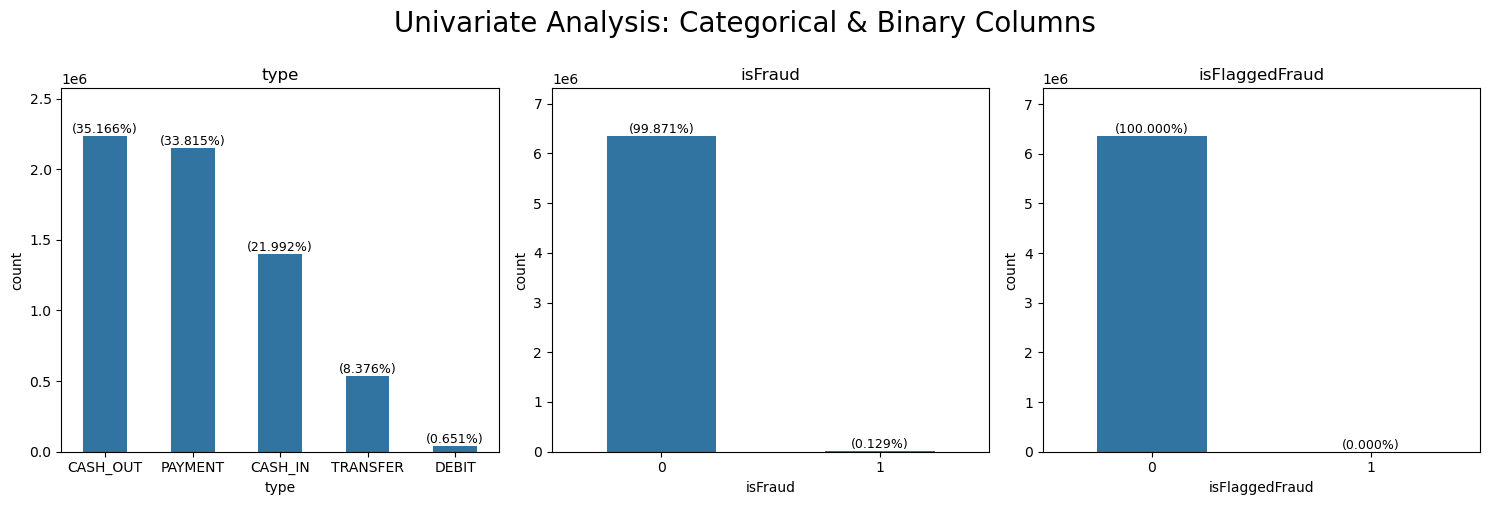

In [11]:
# Plot categorical and binary columns  

categorical_binary_columns = ['type', 'isFraud', 'isFlaggedFraud']
fig, ax = plt.subplots(1, 3, figsize=(15,5))

for i, col in enumerate(categorical_binary_columns):
    value_counts = df[col].value_counts()    
    sns.barplot(value_counts, width=0.5, ax=ax[i])
    ax[i].set_title(col)
    ax[i].margins(y=0.15)

    total = value_counts.sum()
    for bar, count in zip(ax[i].patches, value_counts):
        percentage = f"({count / total * 100:.3f}%)"
        # label = f"{count:,}\n{percentage}" # this is adding both count and % in chart
        label = f"{percentage}"
        ax[i].text(
            bar.get_x() + bar.get_width() / 2,  # x: center of bar
            bar.get_height(),                    # y: top of bar
            label,
            ha='center', va='bottom',
            fontsize=9
        )

plt.suptitle('Univariate Analysis: Categorical & Binary Columns', y=1, fontsize=20)
plt.tight_layout()
plt.show()



- isFraud is our target variable. Theres 8213 fraud or 0.13% (imbalance)
    - need investigation, because of this imbalance, model may learn that all transactions are "not fraud".
- only 16 were flagged as fraud out of approx. 6 million rows - is it worth keeping this column?
- Transactions with type: Debit is the least and cash_out is the most, wonder which types contain frauds or do they all contain fraud?


**Looking into numerical features**


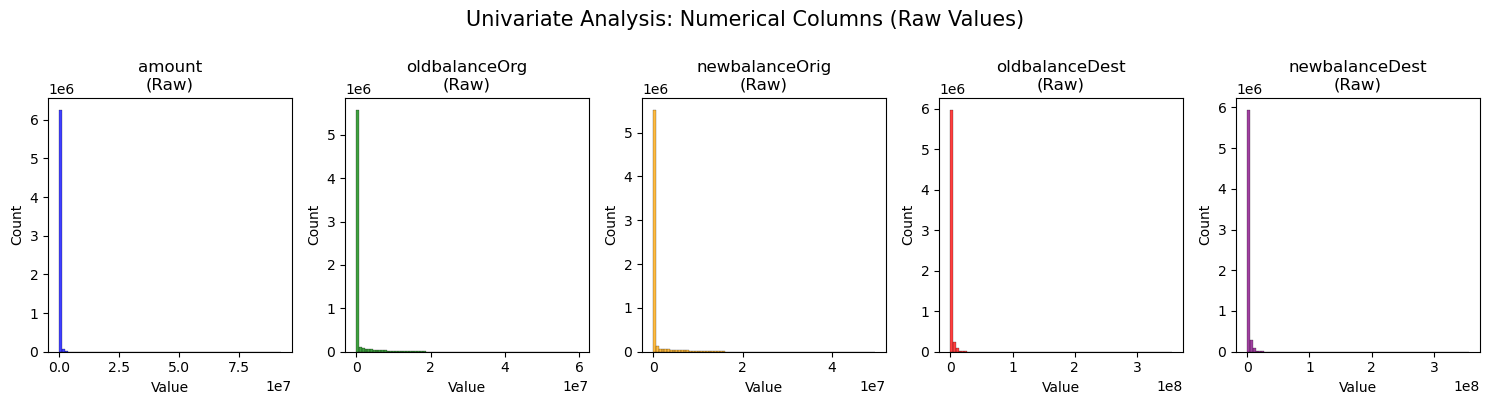

In [45]:
#Plot of numerical columns with raw values

numerical_columns = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
fig, ax = plt.subplots(1, 5, figsize=(15,4))
colors = ['blue', 'green', 'orange', 'red', 'purple']
# colors = sns.color_palette("tab10", n_colors=len(numerical_columns))

for i, col in enumerate(numerical_columns): 
    color = colors[i]
    sns.histplot(df[col], ax=ax[i], bins=80, color=color)
    ax[i].set_title(f"{col}\n(Raw)")
    ax[i].set_xlabel(f"Value")
     

plt.suptitle('Univariate Analysis: Numerical Columns (Raw Values)', y=1, fontsize=15)
plt.tight_layout()
plt.show()

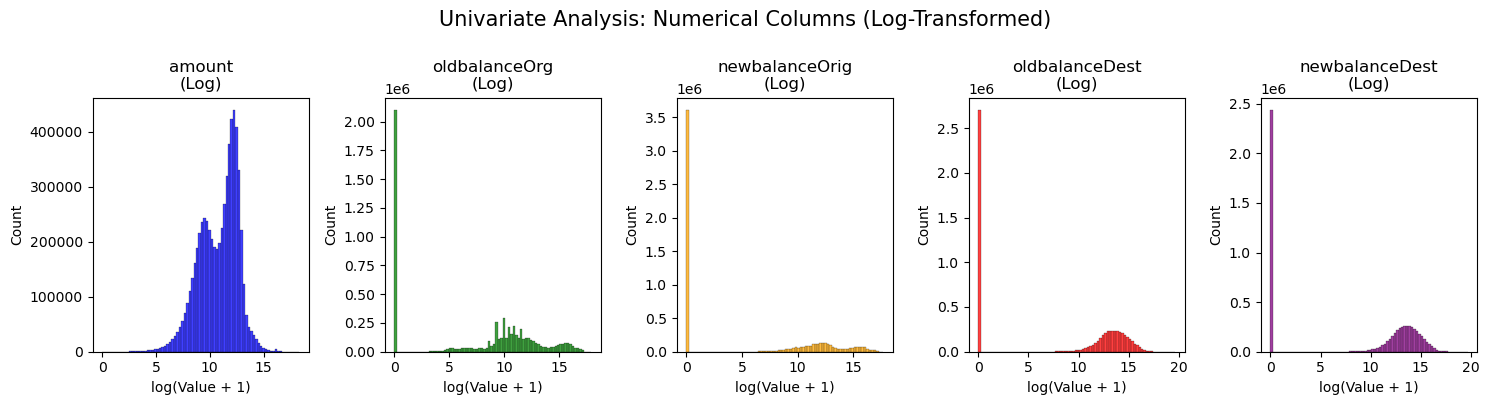

In [47]:
#Plot of numerical columns log-transformed

fig, ax = plt.subplots(1, 5, figsize=(15,4))

for i, col in enumerate(numerical_columns): 
    color = colors[i]
    sns.histplot(np.log1p(df[col]), ax=ax[i], bins=80, color=color)
    ax[i].set_title(f"{col}\n(Log)")
    ax[i].set_xlabel(f"log(Value + 1)")

plt.suptitle('Univariate Analysis: Numerical Columns (Log-Transformed)', y=1, fontsize=15)
plt.tight_layout()
plt.show()

- As we see in the plot with raw values, the datapoints are heavily skewed
- We applied log(Value+1) on these features to have a better sense of what the data is showing us, the balances are still showing skewness, while amount showed a little more promising plot (with two peaks) 
- Even after Log-Transform, theres still a lot of transactions that show zeros. THATS SUS!
    - depending on what type of transaction happened, then we can determine if these zeros are actually suspicious.



**ADD MORE TO THIS!!!! WHAT DO YOU SEE IN THE GRAPHS THAT ARE WORTH NOTING?**

### Bivariate Analysis

In [ ]:
# check which type of transactions had fraud
df.groupby('type')['isFraud'].sum()

Shows that type="CASH_OUT" and type="TRANSFER" are the only types of transactions where fraud shows up.

Check for:
1. maybe find relationship which ones were flagged that were actually fraud?

In [ ]:
plt.figure(figsize=(6,4)) 
sns.barplot(df.groupby('type')['isFraud'].mean(), color="#19A64A")
plt.title("Average Fraud by Type")
plt.show()

#### Multivariate Analysis

In [ ]:
# Correlations of numerical features
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


#NOTES:

- use pivot tables and groupby
- Two peaks on amount log-transformed meaning
- 